# Notebook 1 — Exploratory Data Analysis

This notebook explores the two original datasets:

- `ratings.csv`: user–course ratings
- `course_genre.csv`: original course metadata
- `final_courses.csv`: processed course metadata used later in the project

The main goal is to understand:
1. the number of users, items, and interactions,
2. sparsity and rating distribution,
3. how many courses are missing from `ratings.csv`.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

PROJECT_ROOT = Path('..').resolve()
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'figures'
MODELS_DIR = PROJECT_ROOT / 'models'
RESULTS_DIR = PROJECT_ROOT / 'results'

sys.path.append(str(PROJECT_ROOT))
import utils_recommender as ur
ur.ensure_dirs(FIGURES_DIR, MODELS_DIR, RESULTS_DIR)

In [2]:
ratings = pd.read_csv(DATA_RAW / 'ratings.csv')
course_genre = pd.read_csv(DATA_RAW / 'course_genre.csv')
final_courses = pd.read_csv(DATA_PROCESSED / 'final_courses.csv')

print('ratings shape       :', ratings.shape)
print('course_genre shape  :', course_genre.shape)
print('final_courses shape :', final_courses.shape)

ratings shape       : (233306, 3)
course_genre shape  : (307, 16)
final_courses shape : (307, 17)


In [3]:
print('Unique users      :', ratings['user'].nunique())
print('Unique rated items:', ratings['item'].nunique())
print('Total courses     :', final_courses['COURSE_ID'].nunique())

unrated_courses = final_courses[~final_courses['COURSE_ID'].isin(ratings['item'])]
print('Unrated courses   :', len(unrated_courses))

Unique users      : 33901
Unique rated items: 126
Total courses     : 307
Unrated courses   : 181


In [4]:
rating_stats = pd.DataFrame({
    'metric': ['min', 'max', 'mean', 'median', 'std'],
    'value': [
        ratings['rating'].min(),
        ratings['rating'].max(),
        ratings['rating'].mean(),
        ratings['rating'].median(),
        ratings['rating'].std()
    ]
})
rating_stats

,metric,value
0,min,2.000000
1,max,3.000000
2,mean,2.952954
3,median,3.000000
4,std,0.211737


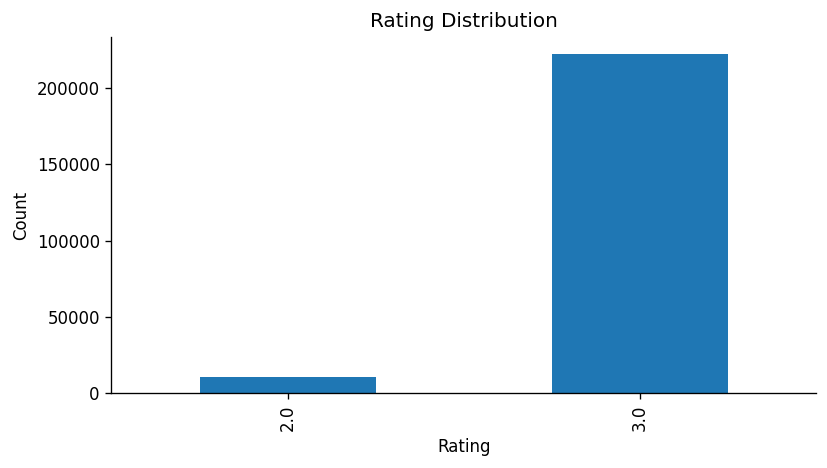

In [5]:
plt.figure(figsize=(7,4))
ratings['rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_rating_distribution.png')
plt.show()

In [6]:
item_counts = ratings.groupby('item').size().sort_values(ascending=False)
user_counts = ratings.groupby('user').size().sort_values(ascending=False)

print(item_counts.describe())
print()
print(user_counts.describe())

count      126.000000
mean      1851.634921
std       2874.579272
min          1.000000
25%        212.250000
50%        634.000000
75%       2247.000000
max      14936.000000
dtype: float64

count    33901.000000
mean         6.881980
std          5.823548
min          1.000000
25%          2.000000
50%          6.000000
75%          9.000000
max         61.000000
dtype: float64


In [7]:
n_users = ratings['user'].nunique()
n_items = final_courses['COURSE_ID'].nunique()
possible = n_users * n_items
observed = len(ratings)
sparsity = 1 - observed / possible

print(f'Possible interactions: {possible:,}')
print(f'Observed interactions: {observed:,}')
print(f'Sparsity            : {sparsity:.4%}')

Possible interactions: 10,407,607
Observed interactions: 233,306
Sparsity            : 97.7583%


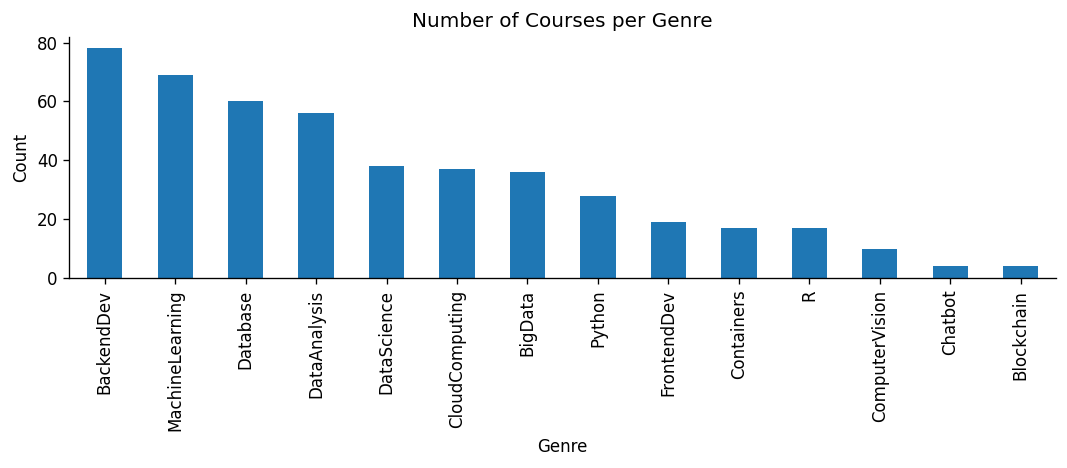

In [8]:
genre_sums = final_courses[ur.GENRE_COLS].sum().sort_values(ascending=False)
plt.figure(figsize=(9,4))
genre_sums.plot(kind='bar')
plt.title('Number of Courses per Genre')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_genre_distribution.png')
plt.show()

In [9]:
unrated_courses.to_csv(DATA_PROCESSED / 'unrated_courses_from_eda.csv', index=False)
print('Saved:', DATA_PROCESSED / 'unrated_courses_from_eda.csv')
unrated_courses[['COURSE_ID', 'TITLE']].head(10)

Saved: /Users/macbook/Downloads/recommender_full_project/data/processed/unrated_courses_from_eda.csv


,COURSE_ID,TITLE
2,GPXX0ZG0EN,consuming restful services using the reactive ...
4,GPXX0Z2PEN,containerizing packaging and running a sprin...
7,GPXX0FTCEN,learn how to use docker containers for iterati...
9,GPXX06RFEN,create your first mongodb database
10,GPXX0SDXEN,testing microservices with the arquillian mana...
14,GPXX0PICEN,create a cryptocurrency trading algorithm in p...
16,GPXX0W7KEN,securing java microservices with eclipse micro...
28,GPXX0A1YEN,validating constraints for javabeans in java m...
34,GPXX03HFEN,fundamentals of javascript through rock paper ...
38,GPXX0IBEN,data science in insurance basic statistical a...
